# Сравнение CLIP и BLIP

CLIP — обычный zero-shot, ничего не дообучали.
BLIP-ITM — предобучена на сопоставление картинки и текста, нр на другом датасете не на MC COCO



In [21]:
import numpy as np
import pandas as pd
from pathlib import Path

emb_dir = Path("../embeddings_output")
data_dir = Path("../DATA")
img_dir = data_dir / "val2017"
clip_img = np.load(emb_dir / "clip_image_embeddings.npy")
blip_img = np.load(emb_dir / "blip_image_embeddings.npy")
clip_txt = np.load(emb_dir / "clip_text_embeddings.npy")
blip_txt = np.load(emb_dir / "blip_text_embeddings.npy")
img_ids = pd.read_csv(emb_dir / "image_ids_order.csv")["image_id"].tolist()
cap_ids = pd.read_csv(emb_dir / "caption_ids_order.csv")["image_id"].tolist()
caps = pd.read_csv(data_dir / "captions.csv")

## 2. Добавляем картинки в FAISS


In [22]:
import faiss

clip_img = clip_img.astype("float32")
blip_img = blip_img.astype("float32")
clip_txt = clip_txt.astype("float32")
blip_txt = blip_txt.astype("float32")
clip_idx = faiss.IndexFlatIP(clip_img.shape[1])
clip_idx.add(clip_img)
blip_idx = faiss.IndexFlatIP(blip_img.shape[1])
blip_idx.add(blip_img)

## 3. Считаем ранги

Все метрики держатся на одной простой штуке — на ранге правильного ответа. Берём подпись, знаем её настоящую картинку. Ищем этой подписью по индексу и смотрим, на каком месте оказалась правильная картинка: на первом, на пятом, на сотом. Это место и есть ранг, чем меньше — тем лучше.

Считаем ранг для каждой подписи, отдельно для CLIP и BLIP. Дальше все метрики получаются из этих рангов парой формул.

In [24]:
id2row = {}
for i, img_id in enumerate(img_ids):
    id2row[img_id] = i

n_img = len(img_ids)

def get_ranks(txt, idx, ids):
    _, found = idx.search(txt, n_img)
    ranks = []
    for i in range(len(ids)):
        correct = id2row[ids[i]]
        rank = found[i].tolist().index(correct) + 1
        ranks.append(rank)
    return np.array(ranks)

clip_ranks = get_ranks(clip_txt, clip_idx, cap_ids)
blip_ranks = get_ranks(blip_txt, blip_idx, cap_ids)

print("первые ранги clip:", clip_ranks[:10])
print("первые ранги blip:", blip_ranks[:10])

первые ранги clip: [35 12 17 57  4 15 70  2  3  2]
первые ранги blip: [ 2  1 33 28  1  1  7 19 16  1]


## Считаем метрики для обоих моделей

In [25]:
def recall(ranks, k):
    return float(np.mean(ranks <= k))

def mrr(ranks):
    return float(np.mean(1.0 / ranks))

def all_metrics(ranks):
    return {
        "Recall@1": recall(ranks, 1),
        "Recall@5": recall(ranks, 5),
        "Recall@10": recall(ranks, 10),
        "Median Rank": float(np.median(ranks)),
        "Mean Rank": float(np.mean(ranks)),
        "MRR": mrr(ranks),
        "mAP": mrr(ranks),
    }

clip_m = all_metrics(clip_ranks)
blip_m = all_metrics(blip_ranks)

table = pd.DataFrame({"CLIP": clip_m, "BLIP": blip_m}).round(3)
table

,CLIP,BLIP
Recall@1,0.355,0.565
Recall@5,0.599,0.812
Recall@10,0.703,0.884
Median Rank,3.000,1.000
Mean Rank,23.043,8.548
MRR,0.472,0.676
mAP,0.472,0.676


## 5. Графики

Таблица это хорошо, но на защите нужны картинки. Рисуем три штуки: столбики Recall@K, распределение рангов и кривую Recall@K по мере роста K.

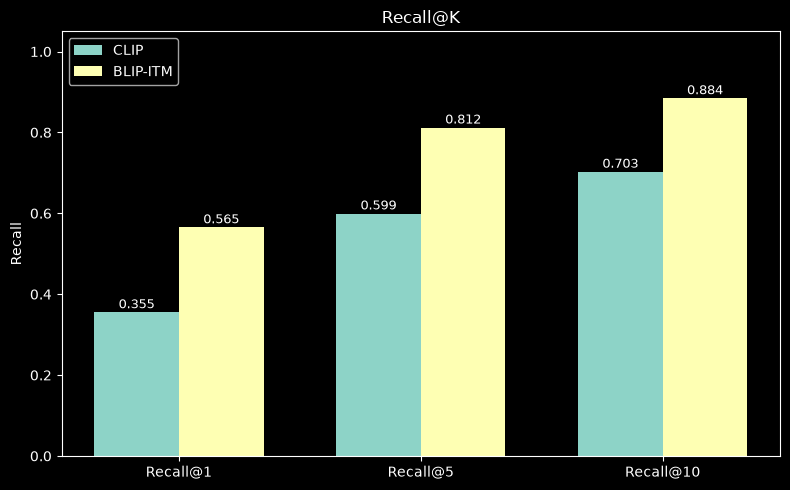

In [26]:
import matplotlib.pyplot as plt

ks = [1, 5, 10]
clip_r = [clip_m["Recall@1"], clip_m["Recall@5"], clip_m["Recall@10"]]
blip_r = [blip_m["Recall@1"], blip_m["Recall@5"], blip_m["Recall@10"]]

x = np.arange(len(ks))
w = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
b1 = ax.bar(x - w/2, clip_r, w, label="CLIP")
b2 = ax.bar(x + w/2, blip_r, w, label="BLIP-ITM")

for bars in [b1, b2]:
    for b in bars:
        h = b.get_height()
        ax.text(b.get_x() + b.get_width()/2, h + 0.01, f"{h:.3f}", ha="center", fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(["Recall@1", "Recall@5", "Recall@10"])
ax.set_ylabel("Recall")
ax.set_ylim(0, 1.05)
ax.set_title("Recall@K")
ax.legend()
plt.tight_layout()
plt.show()

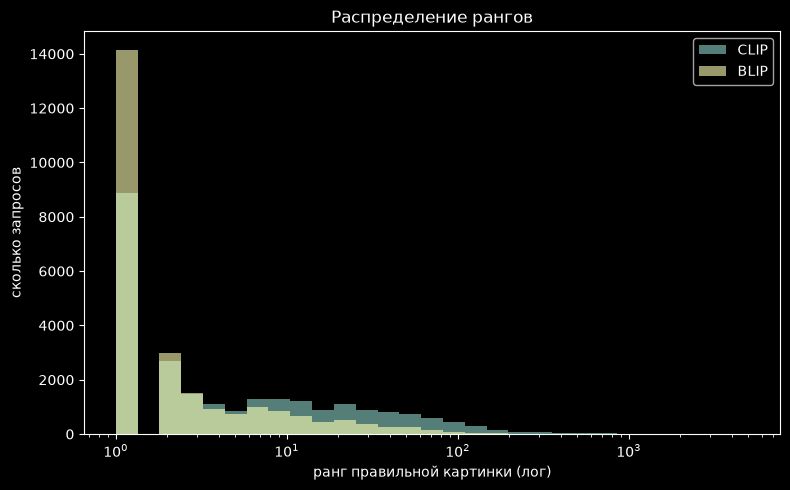

In [27]:
fig, ax = plt.subplots(figsize=(8, 5))
bins = np.logspace(0, np.log10(n_img), 30)
ax.hist(clip_ranks, bins=bins, alpha=0.6, label="CLIP")
ax.hist(blip_ranks, bins=bins, alpha=0.6, label="BLIP")
ax.set_xscale("log")
ax.set_xlabel("ранг правильной картинки (лог)")
ax.set_ylabel("сколько запросов")
ax.set_title("Распределение рангов")
ax.legend()
plt.tight_layout()
plt.show()

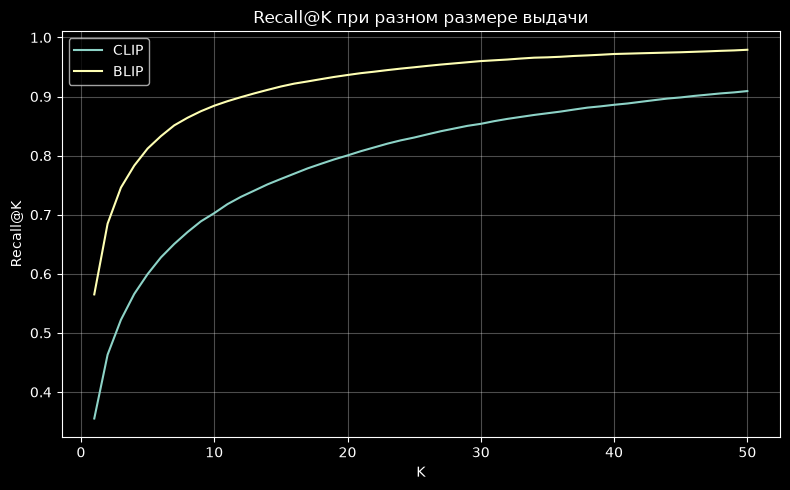

In [28]:
ks2 = range(1, 51)
clip_curve = [recall(clip_ranks, k) for k in ks2]
blip_curve = [recall(blip_ranks, k) for k in ks2]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(list(ks2), clip_curve, label="CLIP")
ax.plot(list(ks2), blip_curve, label="BLIP")
ax.set_xlabel("K")
ax.set_ylabel("Recall@K")
ax.set_title("Recall@K при разном размере выдачи")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

## 6. Проверка  Скорости поиска


In [30]:
import time

def search_time(idx, txt, n=500, k=10):
    ts = []
    for i in range(min(n, len(txt))):
        q = txt[i:i+1]
        t0 = time.time()
        idx.search(q, k)
        ts.append(time.time() - t0)
    return np.mean(ts)

clip_avg = search_time(clip_idx, clip_txt)
blip_avg = search_time(blip_idx, blip_txt)

print(f"CLIP: в среднем {clip_avg*1000:.2f} мс")
print(f"BLIP: в среднем {blip_avg*1000:.2f} мс")

CLIP: в среднем 2.66 мс
BLIP: в среднем 0.37 мс


## 7. поиск подписи по картинке


In [31]:
clip_txt_idx = faiss.IndexFlatIP(clip_txt.shape[1])
clip_txt_idx.add(clip_txt)

blip_txt_idx = faiss.IndexFlatIP(blip_txt.shape[1])
blip_txt_idx.add(blip_txt)

cap_arr = np.array(cap_ids)
id2caps = {}
for img_id in img_ids:
    id2caps[img_id] = set(np.where(cap_arr == img_id)[0].tolist())


In [32]:
def i2t_metrics(img_emb, txt_idx, ids):
    n_txt = txt_idx.ntotal
    best = []
    aps = []
    _, found = txt_idx.search(img_emb, n_txt)
    for i in range(len(ids)):
        correct = id2caps[ids[i]]
        pos = [p + 1 for p, row in enumerate(found[i].tolist()) if row in correct]
        best.append(min(pos))
        pos.sort()
        aps.append(np.mean([k / p for k, p in enumerate(pos, start=1)]))
    best = np.array(best)
    return {
        "Recall@1": recall(best, 1),
        "Recall@5": recall(best, 5),
        "Recall@10": recall(best, 10),
        "Median Rank": float(np.median(best)),
        "Mean Rank": float(np.mean(best)),
        "MRR": mrr(best),
        "mAP": float(np.mean(aps)),
    }

clip_i2t = i2t_metrics(clip_img, clip_txt_idx, img_ids)
blip_i2t = i2t_metrics(blip_img, blip_txt_idx, img_ids)

pd.DataFrame({"CLIP": clip_i2t, "BLIP": blip_i2t}).round(3)

,CLIP,BLIP
Recall@1,0.561,0.723
Recall@5,0.796,0.903
Recall@10,0.869,0.948
Median Rank,1.000,1.000
Mean Rank,7.141,2.979
MRR,0.666,0.803
mAP,0.415,0.588
